# Поиск изображений по текстовому запросу

Нужно проверить идею поиска изображений по описанию. Модель получает вектор текста и вектор изображения. Затем она оценивает соответствие пары. По этой оценке изображения можно упорядочить.

В работе используются TF-IDF и BERT для текста. Для изображений используется ResNet50. Основная метрика качества равна full-catalog NDCG@5.

In [1]:
import os
import re
import urllib.request
import warnings
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.dummy import DummyRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import ndcg_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import callbacks, layers, models
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing import image as kimage

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_DETERMINISTIC_OPS"] = "1"

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

for gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(gpu, True)

try:
    tf.config.experimental.enable_op_determinism()
except Exception as error:
    print("Не удалось включить полную детерминированность", error)

sns.set_style("whitegrid")
print("TensorFlow", tf.__version__)
print("GPU", tf.config.list_physical_devices("GPU"))

TensorFlow 2.10.1
GPU [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Исследовательский анализ данных

Сначала ищем данные в локальных папках и в `/datasets`. Этот шаг находится в блоке `try`. Если данных нет, блок `except` загружает архив с S3 и распаковывает его в папку `to_upload`. Служебные файлы не распаковываются.

In [2]:
DATA_URL = "https://code.s3.yandex.net/datasets/dsplus_integrated_project_4.zip"
DATA_CANDIDATES = ["../.data/task5/to_upload", "to_upload", "/datasets/to_upload", "/datasets"]
REQUIRED_FILES = [
    "train_dataset.csv",
    "ExpertAnnotations.tsv",
    "CrowdAnnotations.tsv",
    "test_queries.csv",
    "test_images.csv",
]

def has_dataset(folder):
    files_exist = all(os.path.isfile(os.path.join(folder, name)) for name in REQUIRED_FILES)
    image_dirs_exist = all(
        os.path.isdir(os.path.join(folder, name))
        for name in ["train_images", "test_images"]
    )
    return files_exist and image_dirs_exist

def resolve_local_data():
    for folder in DATA_CANDIDATES:
        if has_dataset(folder):
            return folder
    raise FileNotFoundError("Локальные данные не найдены")

def download_data():
    archive_path = "dsplus_integrated_project_4.zip"
    destination = "to_upload"
    print("Загружается архив")
    urllib.request.urlretrieve(DATA_URL, archive_path)
    os.makedirs(destination, exist_ok=True)

    with zipfile.ZipFile(archive_path) as archive:
        members = []
        for info in archive.infolist():
            parts = [part for part in info.filename.replace("\\", "/").split("/") if part]
            if not parts:
                continue
            if "__MACOSX" in parts or ".DS_Store" in parts:
                continue
            members.append((info, parts))

        roots = [parts[:-1] for _, parts in members if parts[-1] == "train_dataset.csv"]
        if not roots:
            raise FileNotFoundError("В архиве нет train_dataset.csv")
        dataset_root = roots[0]

        for info, parts in members:
            if parts[:len(dataset_root)] != dataset_root:
                continue
            relative_parts = parts[len(dataset_root):]
            if not relative_parts or any(part in [".", ".."] for part in relative_parts):
                continue
            target = os.path.join(destination, *relative_parts)
            if info.is_dir():
                os.makedirs(target, exist_ok=True)
                continue
            os.makedirs(os.path.dirname(target), exist_ok=True)
            with archive.open(info) as source, open(target, "wb") as output:
                while True:
                    chunk = source.read(1024 * 1024)
                    if not chunk:
                        break
                    output.write(chunk)

    if not has_dataset(destination):
        raise FileNotFoundError("После распаковки набор данных не найден")
    return destination

try:
    DATA = resolve_local_data()
except FileNotFoundError:
    DATA = download_data()

notebook_dir = os.path.abspath("task5") if os.path.isdir("task5") else os.getcwd()
FEATURE_CACHE_DIR = os.path.join(notebook_dir, "task5_cache")
os.makedirs(FEATURE_CACHE_DIR, exist_ok=True)

train = pd.read_csv(os.path.join(DATA, "train_dataset.csv"))
experts = pd.read_csv(
    os.path.join(DATA, "ExpertAnnotations.tsv"),
    sep="\t",
    header=None,
    names=["image", "query_id", "e1", "e2", "e3"],
)
crowd = pd.read_csv(
    os.path.join(DATA, "CrowdAnnotations.tsv"),
    sep="\t",
    header=None,
    names=["image", "query_id", "frac_yes", "n_yes", "n_no"],
)
test_queries = pd.read_csv(os.path.join(DATA, "test_queries.csv"), sep="|", index_col=0)
test_images = pd.read_csv(os.path.join(DATA, "test_images.csv"))

print("Папка данных", DATA)
print("Обучающие пары", train.shape)
print("Экспертные оценки", experts.shape)
print("Крауд оценки", crowd.shape)
print("Тестовые запросы", test_queries.shape)
print("Тестовые изображения", test_images.shape)
train.head(3)

Папка данных ../.data/task5/to_upload
Обучающие пары (5822, 3)
Экспертные оценки (5822, 5)
Крауд оценки (47830, 5)
Тестовые запросы (500, 3)
Тестовые изображения (100, 1)


,image,query_id,query_text
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
2,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...


Экспертные оценки надежнее. Крауд оценка есть примерно для 40 процентов пар. Поэтому её вес равен 0.2. Вес экспертной оценки равен 0.8.

Экспертное среднее переводится из шкалы от 1 до 4 в шкалу от 0 до 1. Если крауд оценки нет, остается чистая экспертная оценка. Так мы сохраняем все пары. Голосование по большинству не используем. Оно потеряло бы силу непрерывной оценки.

Доля пар с крауд оценкой 40.0 процента
Минимальная цель 0.0
Максимальная цель 1.0
Все экспертные пары сохранены True


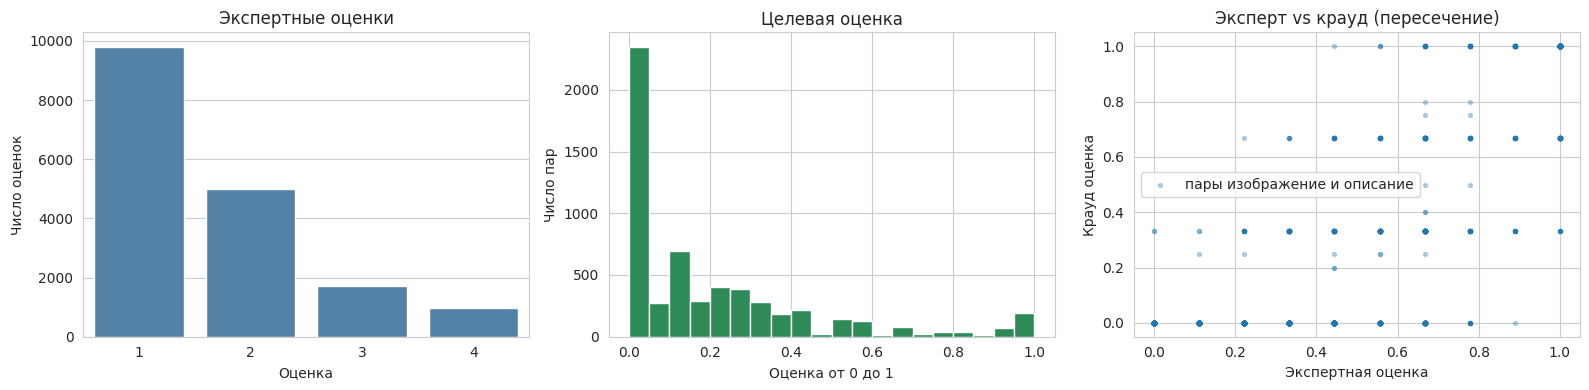

Полное согласие экспертов 58.2 процента
Корреляция экспертной и крауд оценки 0.791


In [3]:
experts["expert_norm"] = (experts[["e1", "e2", "e3"]].mean(axis=1) - 1.0) / 3.0
labels = experts.merge(
    crowd[["image", "query_id", "frac_yes"]],
    on=["image", "query_id"],
    how="left",
    validate="one_to_one",
)
labels["target"] = labels["expert_norm"]
has_crowd = labels["frac_yes"].notna()
labels.loc[has_crowd, "target"] = (
    0.8 * labels.loc[has_crowd, "expert_norm"]
    + 0.2 * labels.loc[has_crowd, "frac_yes"]
)

merged = train.merge(
    labels[["image", "query_id", "expert_norm", "frac_yes", "target"]],
    on=["image", "query_id"],
    how="inner",
    validate="one_to_one",
)

if len(merged) != len(train) or len(merged) != len(labels):
    raise ValueError("Обучающие пары и экспертные оценки не совпадают")

print("Доля пар с крауд оценкой %.1f процента" % (100 * has_crowd.mean()))
print("Минимальная цель", labels["target"].min())
print("Максимальная цель", labels["target"].max())
print("Все экспертные пары сохранены", len(merged) == len(labels))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
all_expert_scores = pd.concat([experts["e1"], experts["e2"], experts["e3"]])
sns.countplot(x=all_expert_scores, ax=axes[0], color="steelblue")
axes[0].set_title("Экспертные оценки")
axes[0].set_xlabel("Оценка")
axes[0].set_ylabel("Число оценок")

axes[1].hist(labels["target"], bins=20, color="seagreen")
axes[1].set_title("Целевая оценка")
axes[1].set_xlabel("Оценка от 0 до 1")
axes[1].set_ylabel("Число пар")

common = labels.dropna(subset=["frac_yes"])
axes[2].scatter(
    common["expert_norm"],
    common["frac_yes"],
    s=8,
    alpha=0.3,
    label="пары изображение и описание",
)
axes[2].set_title("Эксперт vs крауд (пересечение)")
axes[2].set_xlabel("Экспертная оценка")
axes[2].set_ylabel("Крауд оценка")
axes[2].legend()

plt.tight_layout()
plt.show()

full_agreement = (experts[["e1", "e2", "e3"]].nunique(axis=1) == 1).mean()
print("Полное согласие экспертов %.1f процента" % (100 * full_agreement))
print("Корреляция экспертной и крауд оценки %.3f" % common["expert_norm"].corr(common["frac_yes"]))

In [ ]:
train_image_files = {
    name for name in os.listdir(os.path.join(DATA, "train_images"))
    if name.lower().endswith(".jpg")
}
test_image_files = {
    name for name in os.listdir(os.path.join(DATA, "test_images"))
    if name.lower().endswith(".jpg")
}
candidate_counts = merged.groupby("query_id")["image"].nunique()

print("Уникальные обучающие изображения", train["image"].nunique())
print("Уникальные обучающие запросы", train["query_id"].nunique())
print("Файлы обучающих изображений", len(train_image_files))
print("Файлы тестовых изображений", len(test_image_files))
print("Все обучающие изображения найдены", merged["image"].isin(train_image_files).all())
print("Среднее число кандидатов на запрос %.2f" % candidate_counts.mean())
print("Запросы с одним кандидатом", int((candidate_counts == 1).sum()))

Уникальные обучающие изображения 1000
Уникальные обучающие запросы 977
Файлы обучающих изображений 1000
Файлы тестовых изображений 100
Все обучающие изображения найдены True
Среднее число кандидатов на запрос 5.96
Запросы с одним кандидатом 61


## 2. Проверка данных

Фильтр работает в два слоя. Сначала проверяется текст запроса. После поиска проверяется изображение на первом месте. Если текст запроса или найденное изображение запрещены, выводится предупреждение вместо картинки.

Изображение считается запрещённым, если хотя бы одна его собственная подпись содержит слово из списка. Собственные подписи объединяются из обучающей и тестовой частей. Детские изображения остаются в каталогах и участвуют в оценке качества поиска.

Фильтр по подписям находит явные случаи. Детское фото может пройти, если дети не упомянуты ни в одной подписи. Для строгой проверки нужна отдельная модель анализа изображений. Это направление будущей работы.

In [5]:
STOP_WORDS = [
    "child", "children", "kid", "kids", "baby", "babies", "toddler", "toddlers",
    "teen", "teens", "teenager", "teenagers", "boy", "boys", "girl", "girls",
    "infant", "infants", "adolescent", "adolescents", "schoolboy", "schoolboys",
    "schoolgirl", "schoolgirls", "newborn", "newborns", "youngster", "youngsters",
    "kindergarten", "preschool", "preschooler", "preschoolers", "underage",
    "juvenile", "juveniles", "tween", "tweens", "preteen", "preteens",
    "schoolkid", "schoolkids", "kindergartner", "kindergartners",
]
HARM_RX = re.compile(r"\b(?:" + "|".join(map(re.escape, STOP_WORDS)) + r")\b", re.I)

def is_harmful(text):
    return bool(HARM_RX.search(str(text)))

train_source_images = train["query_id"].astype(str).str.split("#", n=1).str[0]
harmful_train_images = set(
    train_source_images.loc[train["query_text"].map(is_harmful)]
)
harmful_test_images = set(
    test_queries.loc[
        test_queries["query_text"].map(is_harmful),
        "image",
    ].astype(str)
)
harmful_images = harmful_train_images | harmful_test_images

before_filter = len(merged)
harmful_query_mask = merged["query_text"].map(is_harmful)
data = merged.loc[~harmful_query_mask].reset_index(drop=True)
harmful_test_count = int(test_queries["query_text"].map(is_harmful).sum())

print("Обучающих изображений с запрещенными подписями", len(harmful_train_images))
print("Тестовых изображений с запрещенными подписями", len(harmful_test_images))
print("Пар до фильтра", before_filter)
print("Пар после фильтра", len(data))
print("Удалено %.1f процента" % (100 * (before_filter - len(data)) / before_filter))
print("Пар с запрещенным текстом запроса", int(harmful_query_mask.sum()))
print("Тестовых запросов с предупреждением по тексту", harmful_test_count)

Обучающих изображений с запрещенными подписями 290
Тестовых изображений с запрещенными подписями 44
Пар до фильтра 5822
Пар после фильтра 4263
Удалено 26.8 процента
Пар с запрещенным текстом запроса 1559
Тестовых запросов с предупреждением по тексту 169


Разбиение по строкам дало бы утечку. Одно изображение могло бы попасть в обе части. Поэтому используем GroupShuffleSplit по изображению. Доля обучающей части равна 0.7.

In [6]:
splitter = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=SEED)
train_indices, valid_indices = next(splitter.split(data, groups=data["image"]))
d_tr = data.iloc[train_indices].reset_index(drop=True)
d_va = data.iloc[valid_indices].reset_index(drop=True)
image_overlap = set(d_tr["image"]) & set(d_va["image"])

print("Обучающих пар", len(d_tr))
print("Валидационных пар", len(d_va))
print("Общих изображений", len(image_overlap))

Обучающих пар 3016
Валидационных пар 1247
Общих изображений 0


## 3. Векторизация изображений (ResNet50)

ResNet50 не обучается. Рассчитанные векторы сохраняются в папку `task5_cache`. Эта папка называется кэшем. Она ускоряет повторный запуск ноутбука. Если кэша нет, ноутбук сам рассчитает признаки и создаст его заново. Каждый вектор содержит 2048 чисел. После загрузки применяется L2 нормировка.

In [7]:
def l2_normalize_rows(values):
    norms = np.linalg.norm(values, axis=1, keepdims=True)
    return values / np.maximum(norms, 1e-12)

def create_image_feature_cache(split, feature_extractor):
    cache_path = os.path.join(FEATURE_CACHE_DIR, split + "_resnet50.npz")
    image_dir = os.path.join(DATA, split + "_images")
    files = sorted(
        name for name in os.listdir(image_dir)
        if name.lower().endswith(".jpg")
    )
    features = np.zeros((len(files), 2048), dtype=np.float32)

    print("Расчет признаков ResNet50 для", split)
    for start in range(0, len(files), 16):
        batch_files = files[start:start + 16]
        batch = np.stack([
            kimage.img_to_array(kimage.load_img(
                os.path.join(image_dir, name),
                target_size=(224, 224),
            ))
            for name in batch_files
        ]).astype(np.float32)
        features[start:start + len(batch_files)] = feature_extractor.predict(
            preprocess_input(batch),
            verbose=0,
        )

    np.savez_compressed(
        cache_path,
        files=np.asarray(files),
        features=features,
    )

missing_image_splits = [
    split for split in ["train", "test"]
    if not os.path.isfile(os.path.join(FEATURE_CACHE_DIR, split + "_resnet50.npz"))
]
if missing_image_splits:
    image_feature_extractor = ResNet50(
        weights="imagenet",
        include_top=False,
        pooling="avg",
    )
    for split in missing_image_splits:
        create_image_feature_cache(split, image_feature_extractor)

def load_image_features(split):
    cache_path = os.path.join(FEATURE_CACHE_DIR, split + "_resnet50.npz")
    with np.load(cache_path, allow_pickle=False) as cache:
        files = cache["files"].astype(str)
        features = l2_normalize_rows(cache["features"].astype(np.float32))
    return {name: vector for name, vector in zip(files, features)}

IMG_TRAIN = load_image_features("train")
IMG_TEST = load_image_features("test")

print("Размер вектора изображения", len(next(iter(IMG_TRAIN.values()))))
print("L2 норма", round(float(np.linalg.norm(next(iter(IMG_TRAIN.values())))), 3))

Размер вектора изображения 2048
L2 норма 1.0


## 4. Векторизация текстов (TF-IDF и BERT)

TF-IDF обучается только на текстах обучающей части. Это защищает от утечки данных.

BERT использует модель `bert-base-nli-mean-tokens`. Модель не дообучается. Эмбеддинги сохраняются в тот же локальный кэш. Если файла нет, ноутбук сам рассчитает эмбеддинги для всех обучающих и тестовых текстов. При повторном запуске готовый файл загружается без нового расчета. После загрузки применяется L2 нормировка.

In [8]:
tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), stop_words="english")
tfidf.fit(d_tr["query_text"].drop_duplicates())

def tfidf_vectors(texts):
    return tfidf.transform(texts).toarray().astype(np.float32)

bert_cache_path = os.path.join(FEATURE_CACHE_DIR, "bert_text.npz")
if not os.path.isfile(bert_cache_path):
    from sentence_transformers import SentenceTransformer

    bert_model_path = "sentence-transformers/bert-base-nli-mean-tokens"
    bert_texts_to_encode = pd.unique(pd.concat(
        [train["query_text"], test_queries["query_text"]],
        ignore_index=True,
    ).astype(str)).tolist()
    print("Расчет эмбеддингов BERT")
    bert_encoder = SentenceTransformer(bert_model_path)
    bert_embeddings_to_save = bert_encoder.encode(
        bert_texts_to_encode,
        batch_size=64,
        convert_to_numpy=True,
        show_progress_bar=True,
    ).astype(np.float32)
    np.savez_compressed(
        bert_cache_path,
        texts=np.asarray(bert_texts_to_encode),
        embeddings=bert_embeddings_to_save,
        model="bert-base-nli-mean-tokens",
    )

with np.load(bert_cache_path, allow_pickle=False) as bert_cache:
    bert_texts = bert_cache["texts"].astype(str)
    bert_embeddings = l2_normalize_rows(bert_cache["embeddings"].astype(np.float32))
    bert_model_name = str(bert_cache["model"])

BERT = {text: vector for text, vector in zip(bert_texts, bert_embeddings)}
BERT_DIM = bert_embeddings.shape[1]

def bert_vectors(texts):
    text_values = [str(text) for text in texts]
    missing = list(dict.fromkeys(text for text in text_values if text not in BERT))
    if missing:
        raise KeyError("В кэше BERT нет текста " + missing[0])
    return np.stack([BERT[text] for text in text_values]).astype(np.float32)

print("Число признаков TF-IDF", len(tfidf.vocabulary_))
print("Модель BERT", bert_model_name)
print("Размер вектора BERT", BERT_DIM)
print("Число текстов в кэше", len(BERT))

Число признаков TF-IDF 1000
Модель BERT bert-base-nli-mean-tokens
Размер вектора BERT 768
Число текстов в кэше 1477


## 5. Объединение векторов

Для регрессионных моделей вход остается объединением двух векторов. Сначала идет текстовый вектор. Затем идет вектор изображения. Все преобразования для обучения настраиваются только по обучающей части.

TF-IDF используется в отдельном Ridge baseline. BERT используется в BERT Ridge, полносвязной сети и two-tower. Так можно сравнить простой способ векторизации текста с более содержательными эмбеддингами.

In [9]:
def image_matrix(files, feature_table):
    return np.stack([feature_table[str(name)] for name in files]).astype(np.float32)

TFIDF_TEXT_TRAIN = tfidf_vectors(d_tr["query_text"])
TFIDF_TEXT_VALID = tfidf_vectors(d_va["query_text"])
BERT_TEXT_TRAIN = bert_vectors(d_tr["query_text"])
BERT_TEXT_VALID = bert_vectors(d_va["query_text"])
IMAGE_TRAIN = image_matrix(d_tr["image"], IMG_TRAIN)
IMAGE_VALID = image_matrix(d_va["image"], IMG_TRAIN)

X_TFIDF_TRAIN = np.hstack([TFIDF_TEXT_TRAIN, IMAGE_TRAIN]).astype(np.float32)
X_TFIDF_VALID = np.hstack([TFIDF_TEXT_VALID, IMAGE_VALID]).astype(np.float32)
X_BERT_TRAIN = np.hstack([BERT_TEXT_TRAIN, IMAGE_TRAIN]).astype(np.float32)
X_BERT_VALID = np.hstack([BERT_TEXT_VALID, IMAGE_VALID]).astype(np.float32)
y_train = d_tr["target"].to_numpy(dtype=np.float32)
y_valid = d_va["target"].to_numpy(dtype=np.float32)

print("Форма TF-IDF выборки", X_TFIDF_TRAIN.shape, X_TFIDF_VALID.shape)
print("Форма BERT выборки", X_BERT_TRAIN.shape, X_BERT_VALID.shape)
print("Порядок признаков", "текст затем изображение")

Форма TF-IDF выборки (3016, 3048) (1247, 3048)
Форма BERT выборки (3016, 2816) (1247, 2816)
Порядок признаков текст затем изображение


## 6. Обучение модели предсказания соответствия

Для оценки выбрана NDCG@5. Пользователь смотрит на список картинок, поэтому важен их порядок. Ошибка на первом месте важнее ошибки на пятом. NDCG учитывает релевантность картинки и ее позицию. Часть `@5` означает, что оцениваются первые пять результатов.

Метрика `validation_grouped_NDCG@5` считается внутри небольших размеченных групп. Она нужна только для выбора параметров. Она не показывает качество поиска по полному каталогу.

Группы с одной картинкой и группы без различий в оценках не учитываются. В них порядок проверить нельзя.

In [10]:
def validation_grouped_ndcg(frame, truth, prediction, k=5):
    scored = frame[["query_id"]].copy()
    scored["truth"] = np.asarray(truth)
    scored["prediction"] = np.asarray(prediction)
    ndcg_values = []

    for _, group in scored.groupby("query_id"):
        if len(group) < 2 or group["truth"].nunique() < 2:
            continue
        relevance = group["truth"].to_numpy(dtype=float)
        scores = group["prediction"].to_numpy(dtype=float)
        group_k = min(k, len(group))
        ndcg_values.append(ndcg_score(relevance[None, :], scores[None, :], k=group_k))

    if not ndcg_values:
        raise ValueError("Нет групп для расчета validation_grouped_NDCG@5")
    return float(np.mean(ndcg_values))

Сначала реализуем подход из ТЗ. Модель получает объединение вектора текста и вектора ResNet50. Цель равна 0.8 от экспертной оценки и 0.2 от крауд оценки. DummyRegressor задает простой ориентир. Отдельные Ridge обучаются на TF-IDF и BERT внутри Pipeline. StandardScaler в каждом Pipeline настраивается только по обучающей части.

Полносвязная сеть использует отдельный StandardScaler. Для нее проверяется небольшая сетка параметров. Ridge и полносвязная сеть выбираются по `validation_grouped_NDCG@5`. Выход полносвязной сети лежит от 0 до 1. Функция потерь равна MSE. Полносвязная сеть обучается на CPU для воспроизводимости.

In [11]:
def build_dense_network(input_dim, units, dropout, learning_rate):
    network = models.Sequential([layers.Input(shape=(input_dim,))])
    for unit_count in units:
        network.add(layers.Dense(unit_count, activation="relu"))
        network.add(layers.Dropout(dropout))
    network.add(layers.Dense(1, activation="sigmoid"))
    network.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"],
    )
    return network

def predict_regression_bundle(bundle, features):
    if bundle["kind"] == "dense_network":
        scaled = bundle["scaler"].transform(features).astype(np.float32)
        return bundle["model"].predict(scaled, verbose=0).ravel()
    return bundle["model"].predict(features).ravel()

MODEL_BUNDLES = {}
SELECTION_ROWS = []

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_BERT_TRAIN, y_train)
MODEL_BUNDLES["Dummy"] = {
    "kind": "sklearn",
    "model": dummy,
    "text_function": bert_vectors,
}

ridge_feature_sets = [
    ("TF-IDF Ridge", X_TFIDF_TRAIN, X_TFIDF_VALID, tfidf_vectors),
    ("BERT Ridge", X_BERT_TRAIN, X_BERT_VALID, bert_vectors),
]

for ridge_name, ridge_train, ridge_valid, text_function in ridge_feature_sets:
    best_ridge_score = -np.inf
    best_ridge = None
    best_ridge_alpha = None

    for alpha in [0.1, 1.0, 10.0, 100.0]:
        ridge_candidate = Pipeline([
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=alpha)),
        ])
        ridge_candidate.fit(ridge_train, y_train)
        ridge_prediction = ridge_candidate.predict(ridge_valid)
        ridge_score = validation_grouped_ndcg(d_va, y_valid, ridge_prediction)
        SELECTION_ROWS.append({
            "model": ridge_name,
            "parameters": "alpha=" + str(alpha),
            "validation_grouped_NDCG@5": ridge_score,
        })
        if ridge_score > best_ridge_score:
            best_ridge_score = ridge_score
            best_ridge = ridge_candidate
            best_ridge_alpha = alpha

    MODEL_BUNDLES[ridge_name] = {
        "kind": "sklearn",
        "model": best_ridge,
        "text_function": text_function,
        "parameters": {"alpha": best_ridge_alpha},
    }

dense_network_scaler = StandardScaler()
scaled_train = dense_network_scaler.fit_transform(X_BERT_TRAIN).astype(np.float32)
scaled_valid = dense_network_scaler.transform(X_BERT_VALID).astype(np.float32)
parameter_grid = [
    (units, dropout, learning_rate)
    for units in [(512, 128), (256, 64)]
    for dropout in [0.3, 0.4]
    for learning_rate in [1e-3, 5e-4]
]
best_dense_network_score = -np.inf
best_dense_network_parameters = None
best_dense_network_weights = None

for units, dropout, learning_rate in parameter_grid:
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    with tf.device("/CPU:0"):
        network = build_dense_network(
            scaled_train.shape[1],
            units=units,
            dropout=dropout,
            learning_rate=learning_rate,
        )
        network.fit(
            scaled_train,
            y_train,
            validation_data=(scaled_valid, y_valid),
            epochs=80,
            batch_size=64,
            callbacks=[callbacks.EarlyStopping(patience=8, restore_best_weights=True)],
            verbose=0,
        )
        prediction = network.predict(scaled_valid, verbose=0).ravel()
    dense_network_score = validation_grouped_ndcg(d_va, y_valid, prediction)
    parameter_text = "units=%s dropout=%s learning_rate=%s" % (
        units,
        dropout,
        learning_rate,
    )
    SELECTION_ROWS.append({
        "model": "Полносвязная сеть",
        "parameters": parameter_text,
        "validation_grouped_NDCG@5": dense_network_score,
    })
    if dense_network_score > best_dense_network_score:
        best_dense_network_score = dense_network_score
        best_dense_network_parameters = {
            "units": units,
            "dropout": dropout,
            "learning_rate": learning_rate,
        }
        best_dense_network_weights = network.get_weights()

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)
with tf.device("/CPU:0"):
    best_dense_network = build_dense_network(
        scaled_train.shape[1],
        **best_dense_network_parameters,
    )
    best_dense_network.set_weights(best_dense_network_weights)

MODEL_BUNDLES["Полносвязная сеть (baseline)"] = {
    "kind": "dense_network",
    "model": best_dense_network,
    "scaler": dense_network_scaler,
    "parameters": best_dense_network_parameters,
    "text_function": bert_vectors,
}

selection_results = pd.DataFrame(SELECTION_ROWS).sort_values(
    ["model", "validation_grouped_NDCG@5"],
    ascending=[True, False],
).reset_index(drop=True)

print("Параметры TF-IDF Ridge", MODEL_BUNDLES["TF-IDF Ridge"]["parameters"])
print("Параметры BERT Ridge", MODEL_BUNDLES["BERT Ridge"]["parameters"])
print(
    "Параметры полносвязной сети",
    MODEL_BUNDLES["Полносвязная сеть (baseline)"]["parameters"],
)
print("validation_grouped_NDCG@5 нужна только для выбора параметров")
selection_results.round(4)

Параметры TF-IDF Ridge {'alpha': 100.0}
Параметры BERT Ridge {'alpha': 100.0}
Параметры полносвязной сети {'units': (512, 128), 'dropout': 0.3, 'learning_rate': 0.0005}
validation_grouped_NDCG@5 нужна только для выбора параметров


,model,parameters,validation_grouped_NDCG@5
0,BERT Ridge,alpha=100.0,0.8299
1,BERT Ridge,alpha=10.0,0.8282
2,BERT Ridge,alpha=0.1,0.8270
3,BERT Ridge,alpha=1.0,0.8269
4,Полносвязная сеть,"units=(512, 128) dropout=0.3 learning_rate=0.0005",0.9018
5,Полносвязная сеть,"units=(512, 128) dropout=0.3 learning_rate=0.001",0.8979
6,Полносвязная сеть,"units=(512, 128) dropout=0.4 learning_rate=0.001",0.8971
7,Полносвязная сеть,"units=(512, 128) dropout=0.4 learning_rate=0.0005",0.8959
8,Полносвязная сеть,"units=(256, 64) dropout=0.3 learning_rate=0.0005",0.8934
9,Полносвязная сеть,"units=(256, 64) dropout=0.4 learning_rate=0.0005",0.8910


Линейная регрессия на объединении векторов дает порядок изображений который не зависит от запроса. Для каждого запроса получается один и тот же порядок. Причина в том что вклады текста и изображения просто складываются.

Поэтому добавляем CLIP-подобную two-tower модель. Она проецирует текст и изображение в общее пространство. Соответствие равно косинусу между векторами.

Методология ТЗ соблюдена. Модель по-прежнему получает вектор текста и вектор картинки и предсказывает их соответствие. Улучшение применил для повышения качества т.к. между прогонами в результате из 10 тестовых картинок не было ни 1 совпадения.

Обе башни используют те же замороженные признаки BERT и ResNet50. Проекции имеют размер 256. Внутри используется GELU активация и L2 нормировка. Модель обучается на парах с целью не ниже 0.5. Функция InfoNCE работает в обе стороны. Совпадения по изображению или точному тексту внутри батча маскируются и не считаются негативами. Обучение идет на CPU для воспроизводимости.

Ограничение сравнения состоит в разных обучающих данных. Two-tower видит только положительные пары и случайные негативы внутри батча. Регрессоры видят все размеченные пары, включая негативные.

In [12]:
PROJECTION_DIM = 256
CONTRASTIVE_BATCH_SIZE = 256
CONTRASTIVE_EPOCHS = 60
TEMPERATURE = 0.05

def build_projection_tower(input_dim, tower_name):
    inputs = layers.Input(shape=(input_dim,), name=tower_name + "_input")
    hidden = layers.Dense(PROJECTION_DIM, activation="gelu")(inputs)
    projected = layers.Dense(PROJECTION_DIM)(hidden)
    normalized = layers.Lambda(
        lambda values: tf.math.l2_normalize(values, axis=1),
        name=tower_name + "_l2",
    )(projected)
    return models.Model(inputs, normalized, name=tower_name)

def symmetric_infonce(text_embeddings, image_embeddings, text_ids, image_ids):
    logits = tf.matmul(text_embeddings, image_embeddings, transpose_b=True) / TEMPERATURE
    batch_size = tf.shape(logits)[0]
    same_text = tf.equal(text_ids[:, None], text_ids[None, :])
    same_image = tf.equal(image_ids[:, None], image_ids[None, :])
    diagonal = tf.eye(batch_size, dtype=tf.bool)
    collision_mask = tf.logical_and(
        tf.logical_or(same_text, same_image),
        tf.logical_not(diagonal),
    )
    masked_logits = tf.where(
        collision_mask,
        tf.fill(tf.shape(logits), tf.cast(float("-inf"), logits.dtype)),
        logits,
    )
    labels_batch = tf.range(batch_size)
    text_loss = tf.keras.losses.sparse_categorical_crossentropy(
        labels_batch,
        masked_logits,
        from_logits=True,
    )
    image_loss = tf.keras.losses.sparse_categorical_crossentropy(
        labels_batch,
        tf.transpose(masked_logits),
        from_logits=True,
    )
    return tf.reduce_mean(text_loss) + tf.reduce_mean(image_loss)

positive_mask = y_train >= 0.5
positive_text = BERT_TEXT_TRAIN[positive_mask]
positive_images = IMAGE_TRAIN[positive_mask]
positive_text_ids = pd.factorize(
    d_tr.loc[positive_mask, "query_text"].astype(str),
    sort=False,
)[0].astype(np.int32)
positive_image_ids = pd.factorize(
    d_tr.loc[positive_mask, "image"].astype(str),
    sort=False,
)[0].astype(np.int32)

if len(positive_text) < CONTRASTIVE_BATCH_SIZE:
    raise ValueError("Недостаточно положительных пар для two-tower")

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)
batch_rng = np.random.RandomState(SEED)

with tf.device("/CPU:0"):
    text_tower = build_projection_tower(BERT_TEXT_TRAIN.shape[1], "text_tower")
    image_tower = build_projection_tower(IMAGE_TRAIN.shape[1], "image_tower")
    contrastive_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
    positive_text_tensor = tf.constant(positive_text)
    positive_image_tensor = tf.constant(positive_images)
    positive_text_id_tensor = tf.constant(positive_text_ids)
    positive_image_id_tensor = tf.constant(positive_image_ids)

    @tf.function
    def train_contrastive_batch(batch_indices):
        text_batch = tf.gather(positive_text_tensor, batch_indices)
        image_batch = tf.gather(positive_image_tensor, batch_indices)
        text_id_batch = tf.gather(positive_text_id_tensor, batch_indices)
        image_id_batch = tf.gather(positive_image_id_tensor, batch_indices)

        with tf.GradientTape() as tape:
            text_embeddings = text_tower(text_batch, training=True)
            image_embeddings = image_tower(image_batch, training=True)
            loss_value = symmetric_infonce(
                text_embeddings,
                image_embeddings,
                text_id_batch,
                image_id_batch,
            )

        trainable_variables = text_tower.trainable_variables + image_tower.trainable_variables
        gradients = tape.gradient(loss_value, trainable_variables)
        contrastive_optimizer.apply_gradients(zip(gradients, trainable_variables))
        return loss_value

    for epoch in range(CONTRASTIVE_EPOCHS):
        epoch_order = batch_rng.permutation(len(positive_text))
        epoch_losses = []

        for start in range(0, len(epoch_order), CONTRASTIVE_BATCH_SIZE):
            batch_indices = epoch_order[start:start + CONTRASTIVE_BATCH_SIZE]
            if len(batch_indices) < 8:
                continue
            loss_value = train_contrastive_batch(tf.constant(batch_indices))
            epoch_losses.append(float(loss_value))

        if epoch == 0 or (epoch + 1) % 10 == 0:
            print("Эпоха", epoch + 1, "InfoNCE", round(float(np.mean(epoch_losses)), 4))

MODEL_BUNDLES["two-tower (improved)"] = {
    "kind": "two_tower",
    "text_model": text_tower,
    "image_model": image_tower,
    "text_function": bert_vectors,
    "parameters": {
        "projection_dim": PROJECTION_DIM,
        "temperature": TEMPERATURE,
        "epochs": CONTRASTIVE_EPOCHS,
    }
}

print("Положительных пар", len(positive_text))
print("Уникальных положительных текстов", len(np.unique(positive_text_ids)))
print("Уникальных положительных изображений", len(np.unique(positive_image_ids)))
print("Параметры two-tower", MODEL_BUNDLES["two-tower (improved)"]["parameters"])

Эпоха 1 InfoNCE 10.7759
Эпоха 10 InfoNCE 2.3398


Эпоха 20 InfoNCE 1.2053
Эпоха 30 InfoNCE 1.0323


Эпоха 40 InfoNCE 0.9552
Эпоха 50 InfoNCE 0.8886


Эпоха 60 InfoNCE 0.9216
Положительных пар 442
Уникальных положительных текстов 240
Уникальных положительных изображений 266
Параметры two-tower {'projection_dim': 256, 'temperature': 0.05, 'epochs': 60}


Значение `validation_grouped_NDCG@5` может быть оптимистичным. Оно не является оценкой поиска. В разделе 7 модель выбирается по отдельной full-catalog валидации. После выбора test используется только для итогового отчета.

## 7. Валидация, проверка на полном каталоге и демонстрация

Сначала строится валидационный каталог из всех уникальных изображений проверочной части. Правильное изображение определяется по номеру запроса. Запрос участвует в оценке, если его текст разрешен и правильное изображение есть в каталоге. Валидационные изображения не пересекаются с обучающими. Итоговая модель выбирается по основной метрике на полном валидационном каталоге. При равенстве используется средний обратный ранг.

После выбора каждая модель один раз оценивается на тестовой части. Для каждого допустимого тестового запроса модель упорядочивает все 100 изображений. Детские изображения сохраняются в тестовом каталоге. Запросы с запрещенным текстом не участвуют в показателях.

Метрика ранжирования считаются на полном каталоге и показывают качество поиска. Предупреждение является отдельным слоем безопасности при выдаче. Если изображение считается детским, оно не показывается пользователю.

Главная метрика оценивает место известного изображения среди всего каталога. Рядом считаются точность попадания на первые места, средний обратный ранг, медианный ранг и средний ранг. Случайный ориентир получает перемешанные оценки. В тесте размечено одно изображение. Поэтому показатели проверяют совпадение с этим изображением и не оценивают все возможные смысловые совпадения.

Модель с постоянным ответом создает произвольный порядок и служит базой для оценки. Случайный ориентир показывает одну воспроизводимую реализацию.

In [13]:
validation_files = d_va["image"].astype(str).drop_duplicates().tolist()
validation_image_matrix = image_matrix(validation_files, IMG_TRAIN)
validation_file_positions = {
    name: position for position, name in enumerate(validation_files)
}

validation_queries = d_va[["query_id", "query_text"]].drop_duplicates()
if validation_queries["query_id"].duplicated().any():
    raise ValueError("Одному validation query_id соответствует несколько текстов")

validation_queries = validation_queries.copy()
validation_queries["image"] = (
    validation_queries["query_id"].astype(str).str.rsplit("#", n=1).str[0]
)
valid_validation_queries = validation_queries.loc[
    ~validation_queries["query_text"].map(is_harmful)
    & validation_queries["image"].isin(validation_files)
].copy()

if valid_validation_queries.empty:
    raise ValueError("Нет допустимых валидационных запросов")

test_files = [str(name) for name in test_images["image"] if str(name) in IMG_TEST]

test_image_matrix = image_matrix(test_files, IMG_TEST)
test_file_positions = {name: position for position, name in enumerate(test_files)}

if len(test_files) != 100:
    raise ValueError("В полном тестовом каталоге должно быть 100 изображений")

valid_test_queries = test_queries.loc[
    ~test_queries["query_text"].map(is_harmful)
    & test_queries["image"].astype(str).isin(test_files)
].copy()

if valid_test_queries.empty:
    raise ValueError("Нет допустимых тестовых запросов")

def query_scores(query_text, bundle, catalog_image_matrix, catalog_file_positions):
    catalog_size = len(catalog_file_positions)
    if catalog_image_matrix.shape[0] != catalog_size:
        raise ValueError("Матрица и позиции каталога не совпадают")

    text_vector = bundle["text_function"]([query_text])

    if bundle["kind"] == "two_tower":
        catalog_cache = bundle.setdefault("catalog_embedding_cache", {})
        cache_key = id(catalog_image_matrix)
        cache_entry = catalog_cache.get(cache_key)
        if cache_entry is None or cache_entry[0] is not catalog_image_matrix:
            with tf.device("/CPU:0"):
                catalog_embeddings = bundle["image_model"].predict(
                    catalog_image_matrix,
                    verbose=0,
                )
            cache_entry = (catalog_image_matrix, catalog_embeddings)
            catalog_cache[cache_key] = cache_entry
        with tf.device("/CPU:0"):
            text_embedding = bundle["text_model"].predict(text_vector, verbose=0)[0]
        return np.matmul(cache_entry[1], text_embedding)

    repeated_text = np.repeat(text_vector, catalog_size, axis=0)
    features = np.hstack([repeated_text, catalog_image_matrix]).astype(np.float32)
    return predict_regression_bundle(bundle, features)

def full_catalog_metrics(
    model_name,
    queries,
    catalog_image_matrix,
    catalog_file_positions,
    score_function,
):
    ranks = []
    catalog_size = len(catalog_file_positions)

    if catalog_image_matrix.shape[0] != catalog_size:
        raise ValueError("Матрица и позиции каталога не совпадают")

    for query_number, (_, row) in enumerate(queries.iterrows()):
        query_text = str(row["query_text"])
        correct_image = str(row["image"])
        scores = np.asarray(
            score_function(
                query_text,
                query_number,
                catalog_image_matrix,
                catalog_file_positions,
            ),
            dtype=float,
        )

        if scores.shape != (catalog_size,):
            raise ValueError("Модель должна оценить все изображения каталога")

        order = np.argsort(-scores, kind="mergesort")
        rank = int(np.where(order == catalog_file_positions[correct_image])[0][0]) + 1
        ranks.append(rank)

    if not ranks:
        raise ValueError("Нет запросов для full-catalog оценки")

    rank_values = np.asarray(ranks, dtype=float)
    ndcg_values = np.where(
        rank_values <= 5,
        1.0 / np.log2(rank_values + 1.0),
        0.0,
    )
    return {
        "model": model_name,
        "full-catalog NDCG@5": float(np.mean(ndcg_values)),
        "Recall@1": float(np.mean(np.array(ranks) <= 1)),
        "Recall@5": float(np.mean(np.array(ranks) <= 5)),
        "Recall@10": float(np.mean(np.array(ranks) <= 10)),
        "MRR": float(np.mean(1.0 / rank_values)),
        "median rank": float(np.median(rank_values)),
        "mean rank": float(np.mean(rank_values)),
    }

validation_random_rng = np.random.default_rng(SEED)
validation_random_scores = np.stack([
    validation_random_rng.permutation(len(validation_files)).astype(np.float32)
    for _ in range(len(valid_validation_queries))
])

validation_comparison_rows = [
    full_catalog_metrics(
        "random baseline",
        valid_validation_queries,
        validation_image_matrix,
        validation_file_positions,
        lambda query_text, query_number, catalog_matrix, catalog_positions: (
            validation_random_scores[query_number]
        ),
    )
]

for model_name, bundle in MODEL_BUNDLES.items():
    validation_comparison_rows.append(
        full_catalog_metrics(
            model_name,
            valid_validation_queries,
            validation_image_matrix,
            validation_file_positions,
            lambda query_text, query_number, catalog_matrix, catalog_positions,
            current_bundle=bundle: query_scores(
                query_text,
                current_bundle,
                catalog_matrix,
                catalog_positions,
            ),
        )
    )

validation_comparison = pd.DataFrame(validation_comparison_rows)
validation_learned = validation_comparison.loc[
    validation_comparison["model"] != "random baseline"
]
best_model_name = validation_learned.sort_values(
    ["full-catalog NDCG@5", "MRR"],
    ascending=False,
).iloc[0]["model"]
BEST = MODEL_BUNDLES[best_model_name]

test_random_rng = np.random.default_rng(SEED)
test_random_scores = np.stack([
    test_random_rng.permutation(len(test_files)).astype(np.float32)
    for _ in range(len(valid_test_queries))
])

test_comparison_rows = [
    full_catalog_metrics(
        "random baseline",
        valid_test_queries,
        test_image_matrix,
        test_file_positions,
        lambda query_text, query_number, catalog_matrix, catalog_positions: (
            test_random_scores[query_number]
        ),
    )
]

for model_name, bundle in MODEL_BUNDLES.items():
    test_comparison_rows.append(
        full_catalog_metrics(
            model_name,
            valid_test_queries,
            test_image_matrix,
            test_file_positions,
            lambda query_text, query_number, catalog_matrix, catalog_positions,
            current_bundle=bundle: query_scores(
                query_text,
                current_bundle,
                catalog_matrix,
                catalog_positions,
            ),
        )
    )

test_comparison = pd.DataFrame(test_comparison_rows)

best_test_top_images = []
for _, row in valid_test_queries.iterrows():
    scores = query_scores(
        str(row["query_text"]),
        BEST,
        test_image_matrix,
        test_file_positions,
    )
    best_test_top_images.append(test_files[int(np.argmax(scores))])

test_harmful_top_count = sum(
    image_name in harmful_images for image_name in best_test_top_images
)
test_harmful_top_share = test_harmful_top_count / len(valid_test_queries)

print("Изображений в валидационном каталоге", len(validation_files))
print("Допустимых валидационных запросов", len(valid_validation_queries))
print("Лучшая модель по full-catalog validation NDCG@5", best_model_name)
print(validation_comparison.round(4))
print("Изображений в тестовом каталоге", len(test_files))
print("Допустимых тестовых запросов", len(valid_test_queries))
print(
    "Тестовых запросов с предупреждением по первому изображению",
    test_harmful_top_count,
)
print(
    "Доля тестовых запросов с предупреждением по первому изображению %.1f процента"
    % (100 * test_harmful_top_share)
)
print("Итоговая тестовая таблица всех моделей")
test_comparison.round(4)

Изображений в валидационном каталоге 298
Допустимых валидационных запросов 168
Лучшая модель по full-catalog validation NDCG@5 two-tower (improved)
                  model  full-catalog NDCG@5  Recall@1  Recall@5  Recall@10  \
0       random baseline               0.0038    0.0000    0.0060     0.0179   
1                 Dummy               0.0030    0.0000    0.0060     0.0298   
2          TF-IDF Ridge               0.0120    0.0060    0.0179     0.0476   
3            BERT Ridge               0.0115    0.0060    0.0179     0.0417   
4  Полносвязная сеть (baseline)       0.1675    0.1012    0.2321     0.3512   
5  two-tower (improved)               0.2165    0.1190    0.3095     0.4226   

      MRR  median rank  mean rank  
0  0.0150        153.0   149.6786  
1  0.0157        164.5   151.6488  
2  0.0270        125.5   129.9286  
3  0.0258        125.5   131.8274  
4  0.1830         20.0    36.8631  
5  0.2195         15.5    35.2976  
Изображений в тестовом каталоге 100
Допустимых

,model,full-catalog NDCG@5,Recall@1,Recall@5,Recall@10,MRR,median rank,mean rank
0,random baseline,0.0359,0.0091,0.0695,0.1239,0.0550,49.0,49.2024
1,Dummy,0.0387,0.0151,0.0604,0.1178,0.0606,54.0,50.6254
2,TF-IDF Ridge,0.0445,0.0151,0.0755,0.1511,0.0681,40.0,43.6586
3,BERT Ridge,0.0445,0.0151,0.0755,0.1511,0.0689,41.0,43.4441
4,Полносвязная сеть (baseline),0.2306,0.1118,0.3414,0.4804,0.2382,11.0,15.4743
5,two-tower (improved),0.2618,0.1541,0.3746,0.5166,0.2633,10.0,19.3535


Ниже показаны десять случайных допустимых запросов с разрешенной правильной картинкой. Слева находится результат модели. Справа находится известное тестовое изображение. Если первое изображение модели запрещено, вместо пары изображений выводится предупреждение.

Запрос The man in the backpack looks to his left .


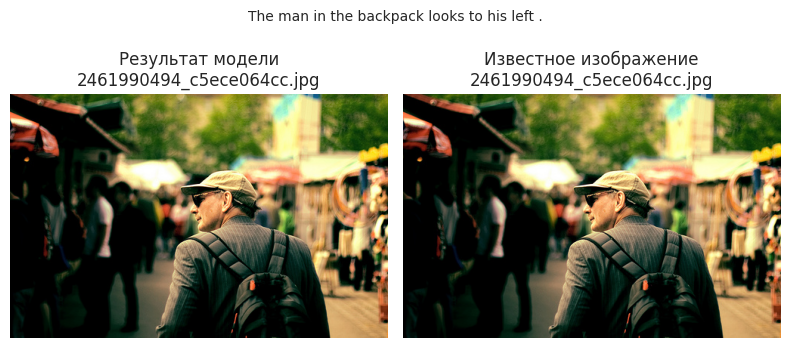

Запрос Two dogs fighting over a toy in the snow .


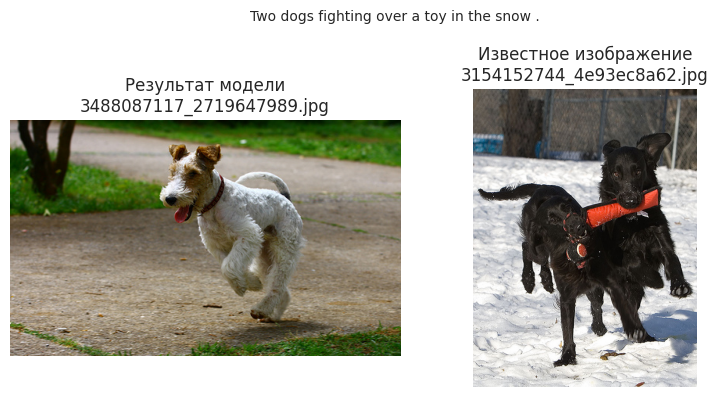

Запрос Two small white dogs are in a yard chasing a red ball .


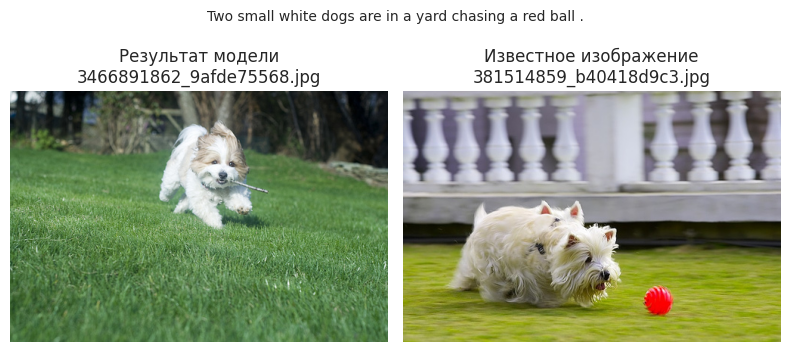

Запрос The shoppers are walking in a store .
This image is unavailable in your country in compliance with local laws.
Запрос Two people , one in blue and one in red , stand in front of a building .


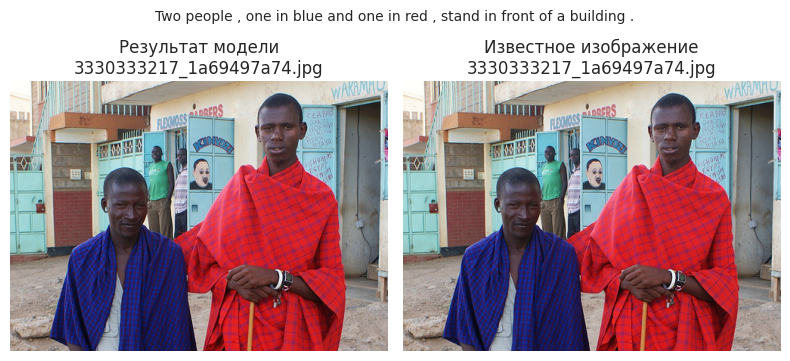

Запрос Two dogs stand in the brown grass .


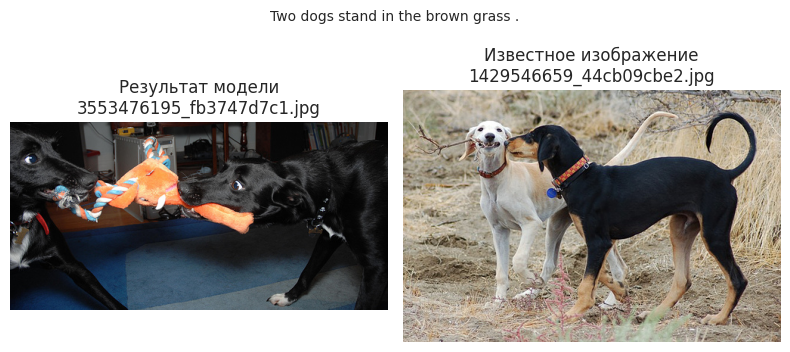

Запрос A blue bird flying over water .


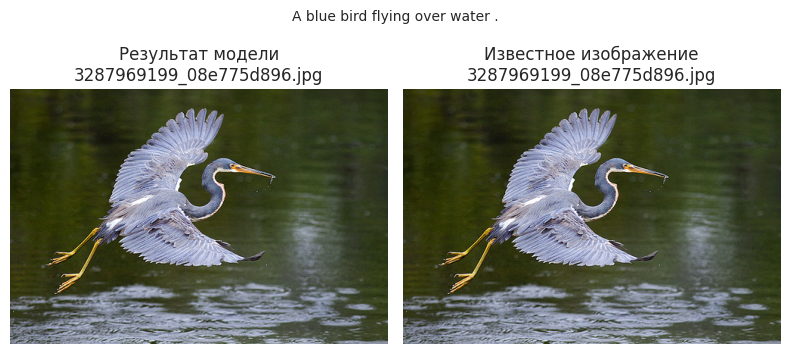

Запрос Little brown and white dog running on the sidewalk .


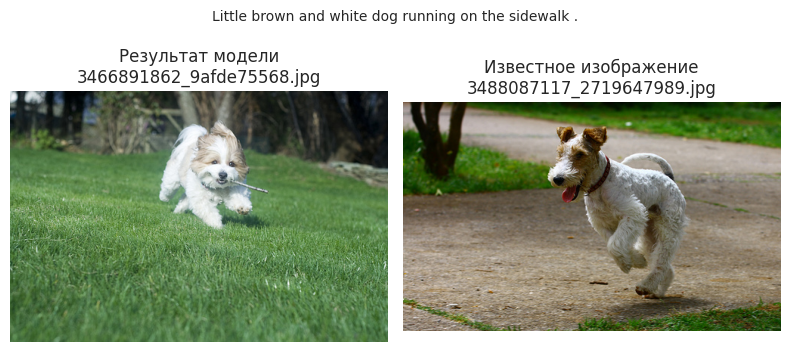

Запрос A long-haired brown and white dog carries a snowball in his mouth .
This image is unavailable in your country in compliance with local laws.
Запрос Cyclists are leaping into the air whilst being watched by spectators .


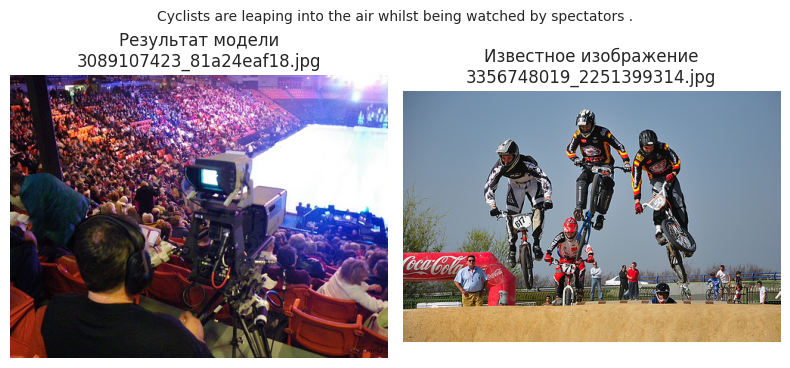

Проверка запрещенного запроса
This image is unavailable in your country in compliance with local laws.


In [ ]:
DISCLAIMER = "This image is unavailable in your country in compliance with local laws."

def search_image(query_text, bundle=BEST, show=True):
    if is_harmful(query_text):
        print(DISCLAIMER)
        return None

    scores = query_scores(
        str(query_text),
        bundle,
        test_image_matrix,
        test_file_positions,
    )
    best_image = test_files[int(np.argmax(scores))]

    if best_image in harmful_images:
        print(DISCLAIMER)
        return None

    if show:
        picture = kimage.load_img(os.path.join(DATA, "test_images", best_image))
        plt.figure(figsize=(4, 4))
        plt.imshow(picture)
        plt.axis("off")
        plt.title(best_image)
        plt.show()

    return best_image

demo_pool = valid_test_queries.loc[
    ~valid_test_queries["image"].astype(str).isin(harmful_images)
]

if len(demo_pool) < 10:
    raise ValueError("Для демонстрации нужно десять допустимых запросов")

demo_rows = demo_pool.sample(n=10, random_state=SEED)

for _, row in demo_rows.iterrows():
    query_text = str(row["query_text"])
    expected_image = str(row["image"])
    print("Запрос", query_text)
    predicted_image = search_image(query_text, show=False)
    if predicted_image is None:
        continue
    if expected_image in harmful_images:
        continue

    predicted_picture = kimage.load_img(os.path.join(DATA, "test_images", predicted_image))
    expected_picture = kimage.load_img(os.path.join(DATA, "test_images", expected_image))

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(predicted_picture)
    axes[0].axis("off")
    axes[0].set_title("Результат модели\n" + predicted_image)
    axes[1].imshow(expected_picture)
    axes[1].axis("off")
    axes[1].set_title("Известное изображение\n" + expected_image)
    fig.suptitle(query_text, fontsize=10)
    plt.tight_layout()
    plt.show()

print("Проверка запрещенного запроса")
search_image("A child is playing in a park")

## 8. Выводы

In [15]:
validation_best_row = validation_comparison.loc[
    validation_comparison["model"] == best_model_name
].iloc[0]
test_best_row = test_comparison.loc[
    test_comparison["model"] == best_model_name
].iloc[0]

print("Итоговая модель по валидации", best_model_name)
print(
    "Валидационная full-catalog NDCG@5",
    round(float(validation_best_row["full-catalog NDCG@5"]), 4),
)
print(
    "Тестовая full-catalog NDCG@5",
    round(float(test_best_row["full-catalog NDCG@5"]), 4),
)

Итоговая модель по валидации two-tower (improved)
Валидационная full-catalog NDCG@5 0.2165
Тестовая full-catalog NDCG@5 0.2618


Главная метрика проекта оценивает место известного изображения среди всех изображений полного каталога. Доля попаданий и ранги дополняют эту оценку.

Целевая оценка использует надежную экспертную разметку и доступную общую разметку. Разбиение по изображениям защищает проверку от утечки. Детские изображения сохраняются в каталогах. Фильтр проверяет текст запроса и изображение в первую очередь. При срабатывании выводится предупреждение вместо картинки.

В работе сохранен регрессионный подход из ТЗ и реально использованы TF-IDF и BERT. CLIP-подобный two-tower добавлен как улучшенный подход. Итоговая модель выбрана по полному валидационному каталогу, а test использован только для финального отчета.

В тестовой таблице у two-tower лучше NDCG@5, Recall@1, Recall@5, Recall@10, MRR и медианный ранг, чем у полносвязной сети. При этом средний ранг немного выше, то есть у two-tower остается тяжелый хвост редких неудачных запросов.

Показатели ранжирования считаются на полном каталоге. Предупреждение работает отдельно как слой безопасности при выдаче. Фильтр по подписям не видит детей, если они не упомянуты в тексте. Отдельная модель анализа изображений на законность выдачи сделает проверку надёжнее.